# Monte Carlo Prediction on Blackjack

**Reproduces S&B Fig 5.1** (§5.1, p.94).

Estimates `V^π` for the fixed policy *"stick on 20 or 21, else hit"* using
first-visit Monte Carlo. Two value estimates are computed and plotted:

1. After **10,000 episodes** -- noisy estimate.
2. After **500,000 episodes** -- converged estimate.

Each is shown as a function of `(player_sum, dealer_show)`, separately for
the usable-ace and no-usable-ace cases.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from rl.envs.blackjack import Blackjack
from rl.monte_carlo.mc_prediction import mc_prediction

from blackjack_plots import plot_fig_5_1_3d, plot_fig_5_1_heatmap

## Policy

The policy under evaluation: *stick on player_sum >= 20, otherwise hit*. Pure
function of `player_sum` -- ignores the dealer card and the usable-ace flag.

In [2]:
env = Blackjack()

def stick_20_21(s, rng):
    player_sum, _, _ = env._decode(s)
    return env.STICK if player_sum >= 20 else env.HIT

## Run MC prediction

First-visit MC over two episode budgets. The 500,000-episode run takes ~10-30
seconds on a typical laptop.

In [3]:
rng = np.random.default_rng(seed=0)

V_10k = mc_prediction(env, stick_20_21, n_episodes=10_000, rng=rng)
V_500k = mc_prediction(env, stick_20_21, n_episodes=500_000, rng=rng)

print(f'V_10k  -> shape={V_10k.shape},  range=[{V_10k.min():+.3f}, {V_10k.max():+.3f}]')
print(f'V_500k -> shape={V_500k.shape}, range=[{V_500k.min():+.3f}, {V_500k.max():+.3f}]')

V_10k  -> shape=(201,),  range=[-1.000, +0.956]
V_500k -> shape=(201,), range=[-0.786, +0.940]


## 3D surface plots (S&B Fig 5.1 style)

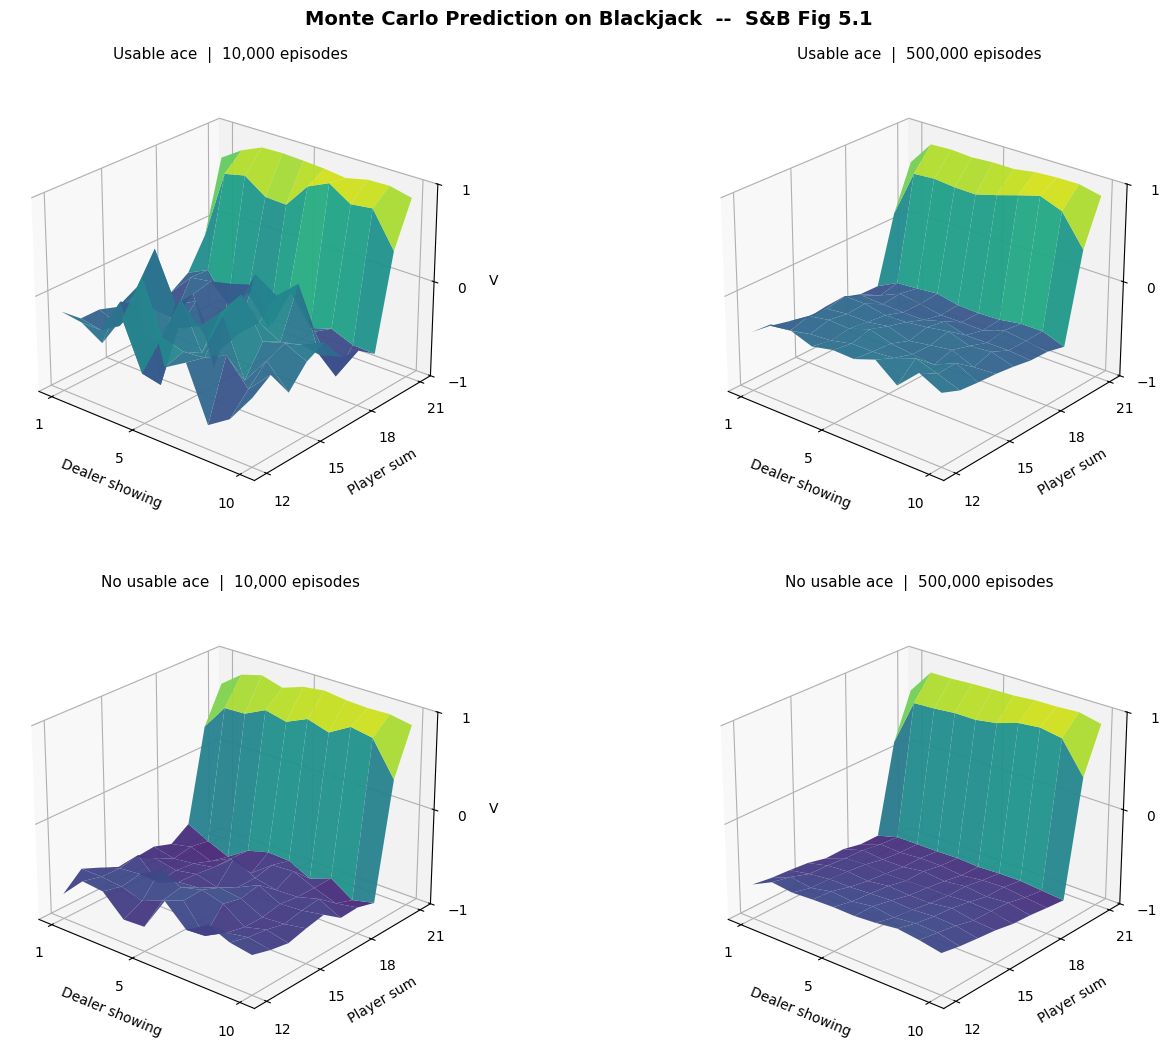

In [4]:
fig = plot_fig_5_1_3d(V_10k, V_500k)
plt.show()

## 2D heatmaps (alternative view)

Same data as above, but with V encoded as colour over the `(player_sum,
dealer_show)` grid. Easier to read off exact values; harder to see the global
shape.

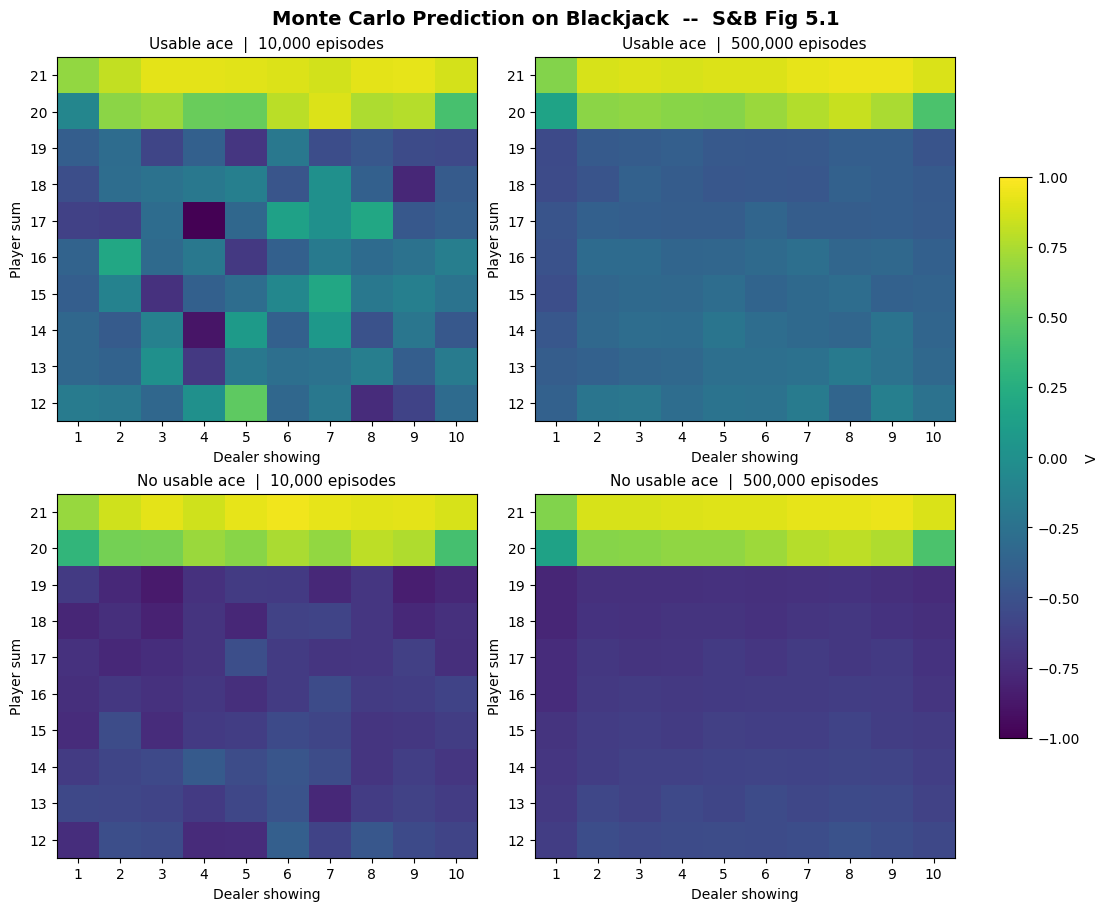

In [5]:
fig = plot_fig_5_1_heatmap(V_10k, V_500k)
plt.show()